## 전처리 파이프라인 개요

@01_eda.ipynb <br/>
EDA에서 검증된 데이터셋(이미지 249장 / 라벨 249건, Pollution 80% / Damaged 20%)을 DeepLabV3+ 학습용 포맷으로 변환합니다. 최종 산출물은 다음과 같습니다.

- 클래스별 정수 라벨이 매핑된 단일채널 마스크 PNG
- 학습/검증/테스트 분할 파일 목록 (CSV)
- 학습용 PyTorch Dataset 클래스 및 증강 파이프라인

ONNX 변환을 염두에 두어 입력 텐서 shape를 고정하고, 증강은 학습 단계에서만 적용합니다.

## 0. 환경 설정 및 상수 정의

- 경로: `IMG_DIR`, `LBL_DIR`, `MASK_DIR`, `SPLIT_DIR`
- 클래스 매핑: `{'background': 0, 'Pollution': 1, 'Damaged': 2}`
- 타겟 해상도: `(IMG_H, IMG_W) = (640, 640)` (DeepLabV3+ 권장값, ONNX 호환)
- 시드 고정: `SEED = 42` (numpy / random / torch 일괄 적용)

타겟 해상도 변경
- (512×512) → (640×640)
- 5×5mm 결함이 리사이즈 후 21.7×38.6px로 안정 검출 영역 → 5×5mm 결함이 리사이즈 후 27.1×48.2px로 안정 검출 영역

In [10]:
import os
import glob
import random
import numpy as np

# 1) 경로
PROJECT   = Path(r'D:\02.study\part4_wj\Battery\Battery_Project')
IMG_DIR   = PROJECT / 'battery_image'
LBL_DIR   = PROJECT / 'battery_label'
MASK_DIR  = PROJECT / 'battery_mask'
SPLIT_DIR = PROJECT / 'battery_splits'
MASK_DIR.mkdir(exist_ok=True)
SPLIT_DIR.mkdir(exist_ok=True)    
os.makedirs(MASK_DIR,  exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

# 2) 클래스 매핑 (DeepLabV3+ 학습용 정수 ID)
CLASS_MAP = {'background': 0, 'Pollution': 1, 'Damaged': 2}
NUM_CLASSES = len(CLASS_MAP)

# 3) 타겟 해상도 (ONNX 입력 shape 고정용)
IMG_H, IMG_W = 640, 640

# 4) 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 5) Sanity gate: EDA에서 확인한 페어링이 여전히 성립하는지 재확인
img_set = {os.path.splitext(os.path.basename(p))[0]
            for p in glob.glob(os.path.join(IMG_DIR, '*.png'))}
lbl_set = {os.path.splitext(os.path.basename(p))[0]
            for p in glob.glob(os.path.join(LBL_DIR, '*.json'))}

assert img_set == lbl_set, \
    f'페어링 불일치: 이미지 단독 {len(img_set - lbl_set)}건, 라벨 단독 {len(lbl_set - img_set)}건'

print(f'설정 완료 | 페어링 {len(img_set)}건 | 클래스 {NUM_CLASSES} | 입력 {IMG_H}x{IMG_W} | seed {SEED}')

설정 완료 | 페어링 249건 | 클래스 3 | 입력 640x640 | seed 42


## 1. JSON 폴리곤 → 마스크 PNG 변환

249개 JSON을 순회하면서 `cv2.fillPoly`로 클래스별 ID를 채운 단일채널 마스크를 생성합니다.

핵심 포인트:
- `dtype=np.uint8`, shape는 원본 이미지 해상도와 동일
- 한 이미지에 결함이 여러 개면 같은 마스크에 누적해서 그림
- 겹침 처리 규칙: **Damaged 우선** (소수 클래스 보존을 위해 Pollution을 먼저 그리고 Damaged로 덮어씀)

    `defects: null` 인 이미지(160건)는 0으로 채운 마스크를 저장해 페어링 유지.
- 저장 시 `cv2.imwrite`로 PNG (압축 손실 없음)

검증: 변환 후 마스크 파일 수 = 249, 단일채널 확인.

### 1. 마스크 생성

In [19]:
import json
import cv2
from collections import Counter

# Damaged 우선: 그리는 순서를 [Pollution, Damaged]로 두면 fillPoly가 덮어쓰는 특성상 Damaged가 위에 옴
DRAW_ORDER = ['Pollution', 'Damaged']

def build_mask(img_path, json_path, class_map, draw_order):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f'이미지 로드 실패: {img_path}')
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    with open(json_path, encoding='utf-8') as f:
        data = json.load(f)
    defects = data.get('defects') or []

    grouped = {name: [] for name in draw_order}
    unknown = []
    for df in defects:
        if df['name'] in grouped:
            grouped[df['name']].append(df['points'])
        else:
            unknown.append(df['name'])

    for cls_name in draw_order:
        cls_id = class_map[cls_name]
        for pts in grouped[cls_name]:
            poly = np.round(np.asarray(pts, dtype=np.float32).reshape(-1, 2)).astype(np.int32)
            cv2.fillPoly(mask, [poly.reshape(-1, 1, 2)], color=cls_id)
    return mask, len(defects), unknown


json_paths = sorted(glob.glob(os.path.join(LBL_DIR, '*.json')))
assert len(json_paths) == 249, f'JSON 수 불일치: {len(json_paths)}'

inst_counter = Counter()      # 결함 인스턴스 카운트 (검증용)
unknown_names = Counter()
zero_defect_imgs = 0

for i, jp in enumerate(json_paths, 1):
    stem = os.path.splitext(os.path.basename(jp))[0]
    ip = os.path.join(IMG_DIR, stem + '.png')
    mask, n_def, unknown = build_mask(ip, jp, CLASS_MAP, DRAW_ORDER)
    if n_def == 0:
        zero_defect_imgs += 1
    for u in unknown:
        unknown_names[u] += 1
    with open(jp, encoding='utf-8') as f:
        for df in (json.load(f).get('defects') or []):
            inst_counter[df['name']] += 1
    cv2.imwrite(os.path.join(MASK_DIR, stem + '.png'), mask)
    if i % 50 == 0 or i == len(json_paths):
        print(f'  진행 {i}/{len(json_paths)}')

print(f'\n마스크 저장 완료 | 결함 0건 이미지 {zero_defect_imgs}건')
print(f'결함 인스턴스: {dict(inst_counter)}')
if unknown_names:
    print(f'⚠ 알 수 없는 결함 이름: {dict(unknown_names)}')

  진행 50/249
  진행 100/249
  진행 150/249
  진행 200/249
  진행 249/249

마스크 저장 완료 | 결함 0건 이미지 160건
결함 인스턴스: {'Pollution': 912, 'Damaged': 227}


## 2. 마스크 검증 (오버레이 시각화)

In [20]:
mask_paths = sorted(glob.glob(os.path.join(MASK_DIR, '*.png')))
assert len(mask_paths) == 249, f'마스크 수 불일치: {len(mask_paths)}'

mask_stems = {os.path.splitext(os.path.basename(p))[0] for p in mask_paths}
assert mask_stems == img_set, '마스크-이미지 stem 불일치'

sample = cv2.imread(mask_paths[0], cv2.IMREAD_UNCHANGED)
assert sample.ndim == 2 and sample.dtype == np.uint8, f'단일채널 uint8 아님: ndim={sample.ndim}, dtype={sample.dtype}'

all_vals = set()
for p in mask_paths:
    all_vals.update(np.unique(cv2.imread(p, cv2.IMREAD_UNCHANGED)).tolist())
expected = set(CLASS_MAP.values())
assert all_vals.issubset(expected), f'예상 외 픽셀값: {all_vals - expected}'

print(f'검증 통과 | 마스크 {len(mask_paths)}건 | dtype={sample.dtype} | 값={sorted(all_vals)}')

검증 통과 | 마스크 249건 | dtype=uint8 | 값=[0, 1, 2]


### 3. 마스크 품질 검증 (오버레이 시각화)

- Pollution / Damaged 각 3장씩 무작위 샘플(시드 고정)
- 색상: Pollution=파랑, Damaged=빨강, alpha=0.4
- 클래스별 전체 픽셀 비율 출력

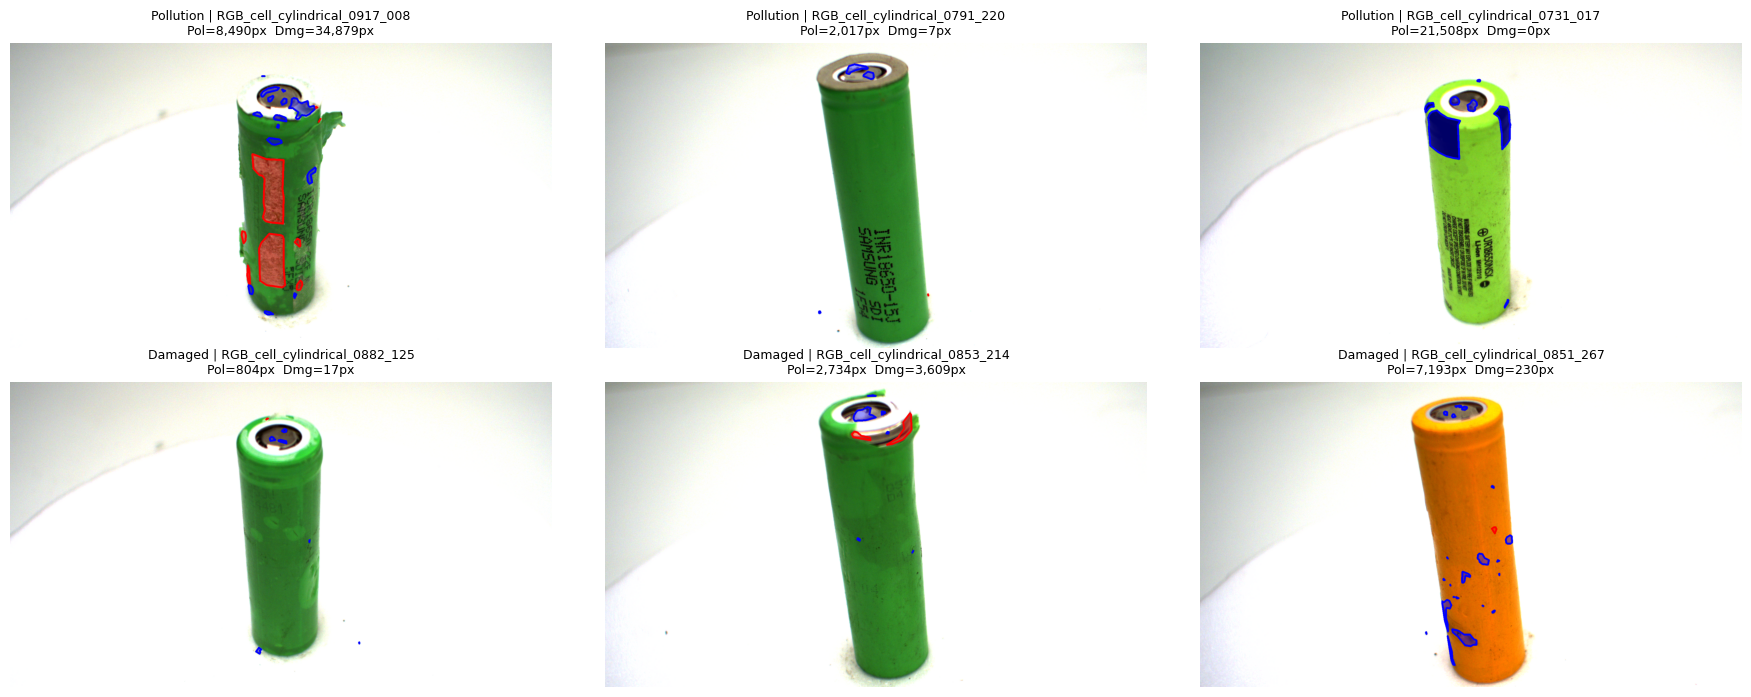

In [21]:
import matplotlib.pyplot as plt

has_pollution, has_damaged = [], []
for jp in json_paths:
    stem = os.path.splitext(os.path.basename(jp))[0]
    with open(jp, encoding='utf-8') as f:
        names = {d['name'] for d in (json.load(f).get('defects') or [])}
    if 'Pollution' in names: has_pollution.append(stem)
    if 'Damaged'   in names: has_damaged.append(stem)

rng = random.Random(SEED)
pick_pol = rng.sample(has_pollution, 3)
pick_dmg = rng.sample(has_damaged,  3)

PALETTE = {1: (255, 0, 0), 2: (0, 0, 255)}  # BGR: Pollution=BLUE, Damaged=Red
OUTLINE_THICKNESS = 6   # 외곽선 굵기


def overlay(img_bgr, mask, alpha=0.4, thickness=OUTLINE_THICKNESS):
    out = img_bgr.copy()
    for cid, color in PALETTE.items():
        sel = mask == cid
        if not sel.any():
            continue
        # 1) 내부 채우기 (반투명 블렌딩)
        layer = np.zeros_like(img_bgr)
        layer[sel] = color
        out[sel] = cv2.addWeighted(img_bgr, 1 - alpha, layer, alpha, 0)[sel]
        # 2) 굵은 외곽선
        cls_mask = (mask==cid).astype(np.uint8) * 255
        contours, _ = cv2.findContours(cls_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, contours, -1, color, thickness=thickness)
    return out

fig, axes = plt.subplots(2, 3, figsize=(18, 7))
for row, (title, stems) in enumerate([('Pollution', pick_pol), ('Damaged', pick_dmg)]):
    for col, stem in enumerate(stems):
        img = cv2.imread(os.path.join(IMG_DIR, stem + '.png'))
        msk = cv2.imread(os.path.join(MASK_DIR, stem + '.png'), cv2.IMREAD_UNCHANGED)
        n_pol = int((msk == 1).sum()); n_dmg = int((msk == 2).sum())
        vis = overlay(img, msk, alpha=0.4)
        axes[row, col].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[row, col].set_title(f'{title} | {stem}\nPol={n_pol:,}px  Dmg={n_dmg:,}px', fontsize=9)
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

### 클래스별 픽셀 비율

In [22]:
totals = np.zeros(NUM_CLASSES, dtype=np.int64)
for p in mask_paths:
    vals, cnt = np.unique(cv2.imread(p, cv2.IMREAD_UNCHANGED), return_counts=True)
    for v, c in zip(vals, cnt):
        totals[int(v)] += int(c)
total_px = totals.sum()

print(f'{"class":<12}{"pixels":>16}{"share":>10}')
for name, cid in CLASS_MAP.items():
    print(f'{name:<12}{totals[cid]:>16,d}{totals[cid] / total_px:>9.3%}')
print(f'\n결함 있는 이미지: {249 - zero_defect_imgs}/249 (배경 전용: {zero_defect_imgs})')

class                 pixels     share
background       513,444,434  99.442%
Pollution          2,229,439   0.432%
Damaged              652,527   0.126%

결함 있는 이미지: 89/249 (배경 전용: 160)


### 섹션 1·2 결과 요약

  | 항목 | 값 |
  |---|---|
  | 마스크 PNG | 249건 (단일채널 uint8, 값 ∈ {0,1,2}) |
  | 결함 있는 이미지 | 89 / 249 |
  | 배경 전용 이미지 | 160 / 249 |
  | 결함 인스턴스 | Pollution 912 / Damaged 227 |
  | 픽셀 비율 (background / Pollution / Damaged) | 99.442% / 0.432% / 0.126% |
  | 겹침 처리 정책 | Damaged 우선 (Pollution → Damaged 순서로 fillPoly) |

  ### 학습 단계 의사결정
  - **클래스 가중치 적용 필수** — 배경 99.44%로 unweighted CE 사용 시 "전부 배경" 예측으로도 high accuracy
  함정에 빠짐
  - 가중치 산출은 섹션 6에서 `sklearn.compute_class_weight` 또는 `total / (num_classes × class_pixels)` 로
  계산해 03 노트북으로 전달
  - Pollution:Damaged 픽셀비 3.4:1 — 인스턴스 단위 stratify(섹션 4)로 충분, 별도 oversampling은 일단 보류

## 3. 리사이즈/패딩 전략

DeepLabV3+ 입력 해상도(512×512)에 맞추는 단계. 원본 해상도는 EDA에서 1920×1080 전수 동일 확인.

### 결정 사항
| 항목 | 결정 |
|---|---|
| 방식 | **단순 resize** (letterbox 없음) |
| 이미지 보간 | `cv2.INTER_AREA` (다운샘플링 최적) |
| 마스크 보간 | `cv2.INTER_NEAREST` (클래스 ID 보존) |
| 저장 정책 | 디스크에 미리 저장하지 않고 Dataset에서 on-the-fly |
| 셀 모델 | **18650 가정 (φ18 × 65mm)** — 추후 확정 시 `CELL_DIAMETER_MM`만 수정 |

### 단순 resize 채택 근거
- 픽셀 면적 letterbox 대비 1.78배 (세로축 압축률이 작음: y는 7.72px/mm vs letterbox 4.35px/mm)
- 5×5mm 결함이 리사이즈 후 21.7×38.6px로 안정 검출 영역
- 추론 시 좌표 역변환이 단순 비례식 `(x/SX, y/SY)`
- 종횡비 1.78→1.0 변환에 따른 원형 결함의 가로 늘어남은 감수 — 작은 점 결함이라 위치·면적 검출이 본질

In [23]:
# ── 캘리브레이션 ───────────────────────────────────────────
CELL_MODEL = '18650'         # 원통형 셀 규격 가정
CELL_DIAMETER_MM = 18.0      # 18650의 실물 지름. 추후 확정 시 이 값만 수정

# 배터리 outline의 짧은 변(=화면상 지름) 평균을 측정해 환산 계수 산출
cell_short_px = []
for jp in json_paths:
    outline = json.load(open(jp, encoding='utf-8')).get('swelling', {}).get('battery_outline')
    if not outline:
        continue
    xs, ys = outline[0::2], outline[1::2]
    cell_short_px.append(min(max(xs) - min(xs), max(ys) - min(ys)))

CELL_SHORT_PX_MEAN = float(np.mean(cell_short_px))
PX_PER_MM_RAW = CELL_SHORT_PX_MEAN / CELL_DIAMETER_MM   # 원본 1920x1080 기준

# ── Resize 헬퍼 (Dataset 클래스에서 on-the-fly로 호출 예정) ──
def resize_image(img_bgr, size=(IMG_W, IMG_H)):
    return cv2.resize(img_bgr, size, interpolation=cv2.INTER_AREA)

def resize_mask(mask, size=(IMG_W, IMG_H)):
    return cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

# ── 리사이즈 후 환산 계수 (검출 스펙 계산용) ─────────────
SX = IMG_W / 1920            # 0.267
SY = IMG_H / 1080            # 0.474
PX_PER_MM_X = PX_PER_MM_RAW * SX
PX_PER_MM_Y = PX_PER_MM_RAW * SY

print(f'캘리브레이션 (셀 {CELL_MODEL}, 지름 {CELL_DIAMETER_MM}mm 가정)')
print(f'  원본    : 1mm = {PX_PER_MM_RAW:.2f}px (셀 짧은변 평균 {CELL_SHORT_PX_MEAN:.0f}px {CELL_DIAMETER_MM}mm)')
print(f'  resize  : 1mm = {PX_PER_MM_X:.2f}px (x) / {PX_PER_MM_Y:.2f}px (y)')
print(f'  스케일  : SX={SX:.3f}, SY={SY:.3f}')
print(f'\n검출 한계 (학습 해상도 한 변 12px = 안정 검출 기준)')
print(f'  최소 검출 결함 크기: {12 / PX_PER_MM_X:.2f}mm × {12 / PX_PER_MM_Y:.2f}mm')

캘리브레이션 (셀 18650, 지름 18.0mm 가정)
  원본    : 1mm = 16.27px (셀 짧은변 평균 293px 18.0mm)
  resize  : 1mm = 5.42px (x) / 9.64px (y)
  스케일  : SX=0.333, SY=0.593

검출 한계 (학습 해상도 한 변 12px = 안정 검출 기준)
  최소 검출 결함 크기: 2.21mm × 1.24mm


### 샘플 시각화 + 결함 크기 분포

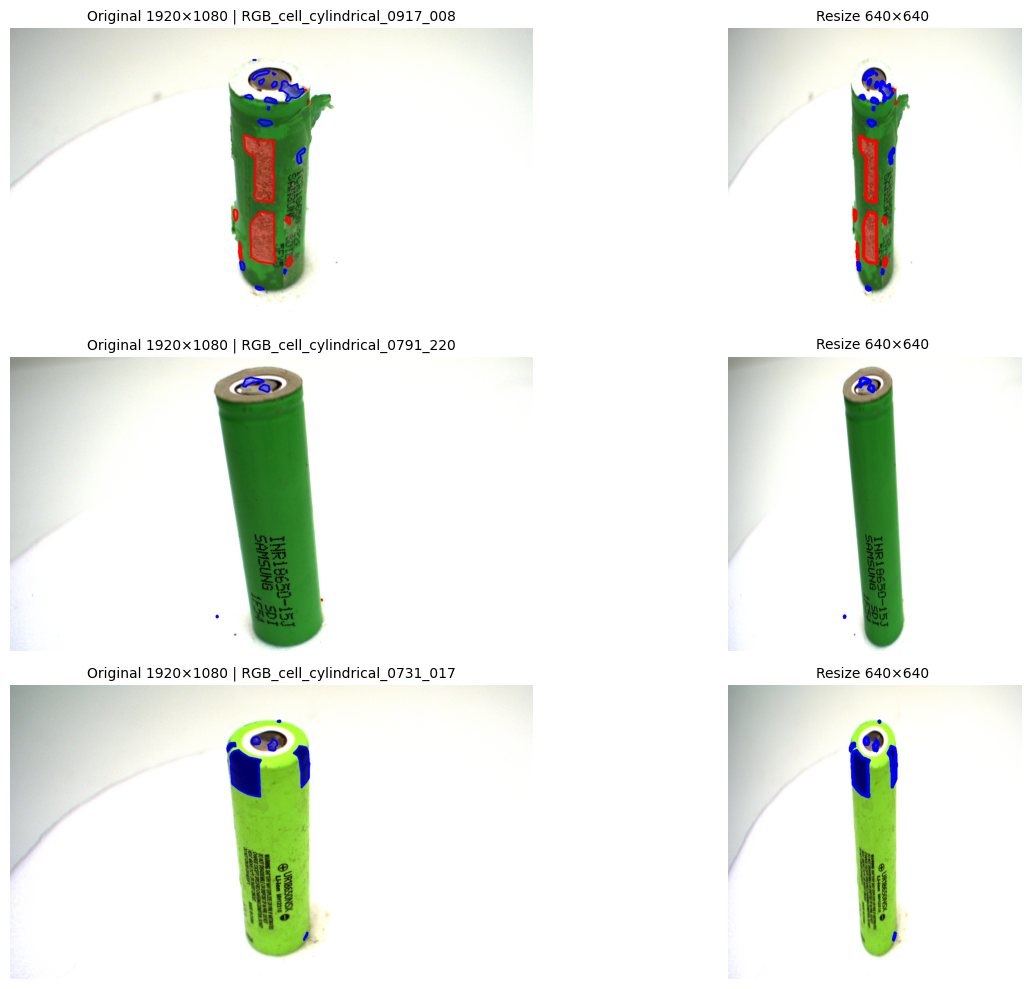

=== 리사이즈 후 결함 크기 분포 (등가 정사각형 한 변, px) ===
  Pollution  n= 925  median=  5.6  p5= 1.0  <8px(비신뢰) 570건 (61.6%)  <1px(손실)  0건
  Damaged    n= 228  median=  9.3  p5= 1.4  <8px(비신뢰) 107건 (46.9%)  <1px(손실)  0건


In [25]:
# 결함 있는 샘플 3장을 원본 vs 리사이즈로 비교
candidates = [s for s in sorted(mask_stems)
            if cv2.imread(os.path.join(MASK_DIR, s + '.png'), cv2.IMREAD_UNCHANGED).max() > 0]
sample_stems = random.Random(SEED).sample(candidates, 3)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for row, stem in enumerate(sample_stems):
    img = cv2.imread(os.path.join(IMG_DIR, stem + '.png'))
    msk = cv2.imread(os.path.join(MASK_DIR, stem + '.png'), cv2.IMREAD_UNCHANGED)
    img_r = resize_image(img); msk_r = resize_mask(msk)

    axes[row, 0].imshow(cv2.cvtColor(overlay(img, msk), cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'Original 1920×1080 | {stem}', fontsize=10); axes[row, 0].axis('off')
    axes[row, 1].imshow(cv2.cvtColor(overlay(img_r, msk_r), cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title(f'Resize 640×640 ', fontsize=10); axes[row, 1].axis('off')
plt.tight_layout(); plt.show()

# 리사이즈 후 결함 크기 분포 — 학습 시 몇 %가 검출 한계 미만인지 정량 확인
print('=== 리사이즈 후 결함 크기 분포 (등가 정사각형 한 변, px) ===')
for cid, name in [(1, 'Pollution'), (2, 'Damaged')]:
    sides = []
    for p in sorted(glob.glob(os.path.join(MASK_DIR, '*.png'))):
        m = resize_mask(cv2.imread(p, cv2.IMREAD_UNCHANGED))
        cls = (m == cid).astype(np.uint8)
        if cls.sum() == 0: continue
        n, _, st, _ = cv2.connectedComponentsWithStats(cls, connectivity=8)
        sides.extend(np.sqrt(st[1:, cv2.CC_STAT_AREA]).tolist())
    a = np.array(sides)
    print(f'  {name:10s} n={len(a):4d}  median={np.median(a):5.1f}  p5={np.percentile(a,5):4.1f}  '
        f'<8px(비신뢰) {(a<8).sum():3d}건 ({(a<8).mean():.1%})  '
        f'<1px(손실) {(a<1).sum():2d}건')

### 섹션 3 결과
- 단순 resize 헬퍼(`resize_image`, `resize_mask`) 정의 완료
- 캘리브레이션 변수(`PX_PER_MM_RAW`, `SX`, `SY`) 글로벌 등록
- 원본 vs 리사이즈 시각 비교로 종횡비 변화 확인

### 검출 한계 실측 (640×640 단순 resize 기준)
| 지표 | Pollution | Damaged |
|---|---|---|
| 리사이즈 후 median 한 변 | **5.6px** (≈1.03mm) | **9.3px** (≈1.72mm) |
| `<8px` 비신뢰 비율 | **61.6%** (570/925) | **46.9%** (107/228) |
| `<1px` 손실 | 0건 | 0건 |
| 검출 가능 최소 결함 | **2.21 × 1.24 mm** (가로 기준 보수적) | |

→ 공식 검출 스펙은 **≥ 3×3mm** 결함 기준으로 공시. 1~3mm는 best-effort.

 ## 4. Train/Val/Test 분할

249장은 크지 않으므로 분할 비율과 stratify가 중요하다.

- **분할 비율**: train 70% / val 15% / test 15%
- **Stratify 기준**: 이미지당 결함 조합 (`clean / pollution / damaged / both`) — Pollution 80% : Damaged 20%
불균형이 각 split에서 유지되도록
- **저장 형식**: 파일명만 1열로 기록한 CSV — 04_finetune의 `BatteryDataset`이 그대로 읽을 수 있는 포맷
- **검증**: 분할 후 각 split의 클래스 픽셀 비율 출력 → 원본 분포와 크게 벗어나지 않는지 확인

### 4-1. split 생성

In [13]:
from sklearn.model_selection import train_test_split
from pathlib import Path
from PIL import Image
import pandas as pd

# 이미지별 stratify 라벨 결정
records = []
for mask_path in sorted(MASK_DIR.glob('*.png')):
    m = np.array(Image.open(mask_path))
    has_pol, has_dmg = (m == 1).any(), (m == 2).any()
    if has_pol and has_dmg:   label = 'both'
    elif has_dmg:             label = 'damaged'
    elif has_pol:             label = 'pollution'
    else:                     label = 'clean'
    records.append({'name': mask_path.stem, 'label': label})

df = pd.DataFrame(records)
print('전체 라벨 분포:')
print(df['label'].value_counts(), '\n')

# 70/15/15 stratified
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

# CSV 저장 (이름만, 헤더 없음 — 04_finetune Dataset이 그대로 읽음)
train_df['name'].to_csv(SPLIT_DIR / 'train.csv', index=False, header=False)
val_df['name'].to_csv(SPLIT_DIR / 'val.csv',     index=False, header=False)
test_df['name'].to_csv(SPLIT_DIR / 'test.csv',   index=False, header=False)

# 메타 CSV도 같이 (디버깅·재현용)
train_df.to_csv(SPLIT_DIR / 'train_meta.csv', index=False)
val_df.to_csv  (SPLIT_DIR / 'val_meta.csv',   index=False)
test_df.to_csv (SPLIT_DIR / 'test_meta.csv',  index=False)

print(f'Train: {len(train_df)}장, Val: {len(val_df)}장, Test: {len(test_df)}장')
print(f'저장 위치: {SPLIT_DIR}')

전체 라벨 분포:
label
clean        160
both          46
pollution     43
Name: count, dtype: int64 

Train: 174장, Val: 37장, Test: 38장
저장 위치: D:\02.study\part4_wj\Battery\Battery_Project\battery_splits


## 4-2. 분할 결과 검증

In [ ]:
# 각 split별 stratify 라벨 분포 확인 (원본과 유사해야 함)
print('=== Split별 라벨 분포 (개수 / 비율) ===\n')
for name, sub in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = sub['label'].value_counts()
    pcts = (counts / counts.sum() * 100).round(1)
    print(f'[{name}] (n={len(sub)})')
    for k in ['clean', 'pollution', 'damaged', 'both']:
        c = counts.get(k, 0)
        p = pcts.get(k, 0.0)
        print(f'  {k:10s} {c:3d}장 ({p:.1f}%)')
    print()

# 픽셀 단위 클래스 비율도 split별로 확인 (class_weight 산정 참고용)
print('=== Split별 픽셀 단위 클래스 비율 ===\n')
for name, sub in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = np.zeros(3, dtype=np.int64)
    for fname in sub['name']:
        m = np.array(Image.open(MASK_DIR / f'{fname}.png'))
        for c in range(3):
            counts[c] += int((m == c).sum())
    total = counts.sum()
    print(f'[{name}] bg={counts[0]/total*100:.2f}%  Poll={counts[1]/total*100:.4f}%Dmg={counts[2]/total*100:.4f}%')

=== Split별 라벨 분포 (개수 / 비율) ===

[Train] (n=174)
  clean      112장 (64.4%)
  pollution   30장 (17.2%)
  damaged      0장 (0.0%)
  both        32장 (18.4%)

[Val] (n=37)
  clean       24장 (64.9%)
  pollution    6장 (16.2%)
  damaged      0장 (0.0%)
  both         7장 (18.9%)

[Test] (n=38)
  clean       24장 (63.2%)
  pollution    7장 (18.4%)
  damaged      0장 (0.0%)
  both         7장 (18.4%)

=== Split별 픽셀 단위 클래스 비율 ===

[Train] bg=99.42%  Poll=0.4526%Dmg=0.1247%
[Val] bg=99.44%  Poll=0.4018%Dmg=0.1602%
[Test] bg=99.53%  Poll=0.3655%Dmg=0.1011%


: 

### 작업 흐름 설명
AI허브 데이터셋과 함께 제공된 **사전학습 DeepLabV3+ 가중치**(`모델2batteryrgb.pt`, 489MB) 발견. <br/>
경로: `pretrained_aihub/2.AI학습모델파일/weights/모델2batteryrgb.pt`

**노선**: 사전학습 모델로 추론 우선 → 결과 평가 → 필요 시 fine-tune.